In [ ]:
from xgboost import XGBRegressor # Import XGBRegressor
import pandas as pd
import numpy as np
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score

In [ ]:
data = pd.read_csv('/content/vvix_unscaled.csv')

# If 'Date' exists, sort by it to prevent accidental shuffling, then set it as index or drop it.
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data = data.sort_values('Date')
    # We will keep date for plotting later, but exclude it from features
    dates = data['Date'].copy()
    data = data.drop('Date', axis=1)

# Feature Engineering (Add extra context)
data['VIX_Rolling_5'] = data['VIX_Close'].rolling(window=5).mean()
data['SPX_Rolling_5'] = data['SPX_Close'].rolling(window=5).mean()

# Define the target
target_column = 'VIX_Close'
y = data[target_column]

# Separate the features
X = data.drop(target_column, axis=1)

# THIS IS THE MAGIC LINE. We push all features forward by 1 day.
# Row index 100 will now contain the target for Day 100, but the features from Day 99.
X_lagged = X.shift(1)

# Recombine and drop the first row (which now has NaNs because Day 0 has no yesterday)
clean_data = pd.concat([X_lagged, y], axis=1).dropna()

# Redefine final, cheat-proof X and y
X_final = clean_data.drop(target_column, axis=1)
y_final = clean_data[target_column]

# Slice the dates array to match the dropped NaN row
dates_final = dates.iloc[1:].reset_index(drop=True)

# Split the data (Avoid shuffling for time-series)
train_size = int(len(X_final) * 0.8)
X_train, X_test = X_final.iloc[:train_size], X_final.iloc[train_size:]
y_train, y_test = y_final.iloc[:train_size], y_final.iloc[train_size:]
dates_test = dates_final.iloc[train_size:]

# Intialize and train (Changed to XGBRegressor for continuous target variable)
model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=4) # Use XGBRegressor instead of XGBClassifier
model.fit(X_train, y_train)

# Make some predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluation scores
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Evaluating directional accuracy
y_test_array = y_test.values
directional_accuracy = np.mean(np.sign(y_test_array[1:]) == np.sign(np.diff(y_pred)))

# Print them out
print("EVALUATION SCORES")
print(f'Mean Squared Error: {mse:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')
print(f'R-squared: {r2:.4f}')
print(f"Directional Accuracy: {directional_accuracy:.4f}")

EVALUATION SCORES
Mean Squared Error: 5.2018
Mean Absolute Error: 1.3513
R-squared: 0.8433
Directional Accuracy: 0.4252


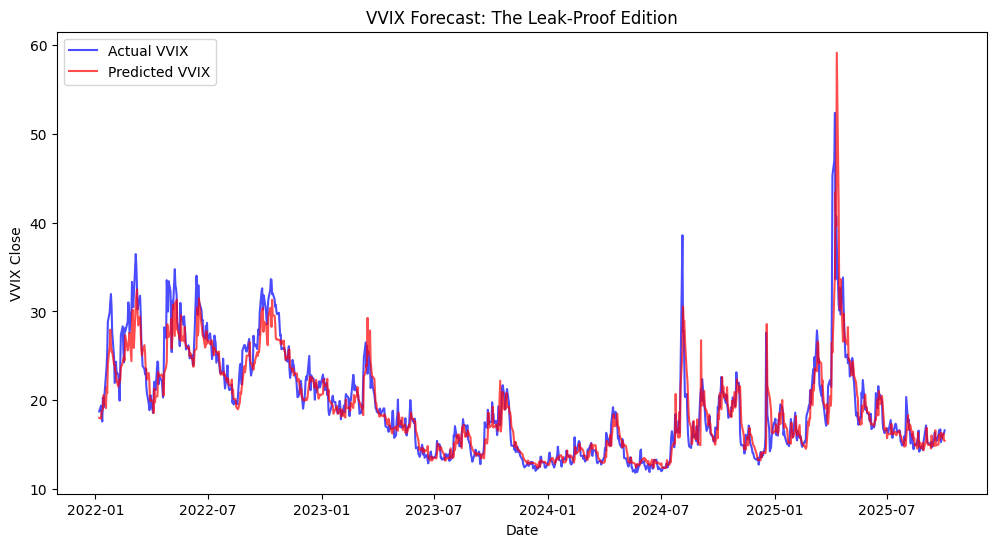

In [ ]:
from matplotlib import pyplot as plt

# Visualizing the predicted vs. actuals
plt.figure(figsize=(12, 6))

# Adjust dates_test to match the length of y_test_array and y_pred
# The mismatch is 4 elements (941 - 937 = 4), so we drop the first 4 dates.
dates_test_aligned = dates_test[len(dates_test) - len(y_test_array):]

plt.plot(dates_test_aligned, y_test_array, label='Actual VVIX', color='blue', alpha=0.7)
plt.plot(dates_test_aligned, y_pred, label='Predicted VVIX', color='red', alpha=0.7)
plt.title('VVIX Forecast: The Leak-Proof Edition')
plt.xlabel('Date')
plt.ylabel('VVIX Close')
plt.legend()
plt.show()

Bar Plot


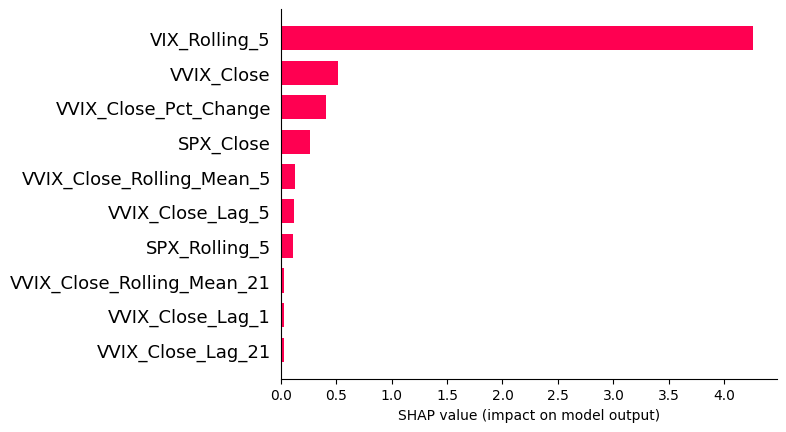

Summary Plot


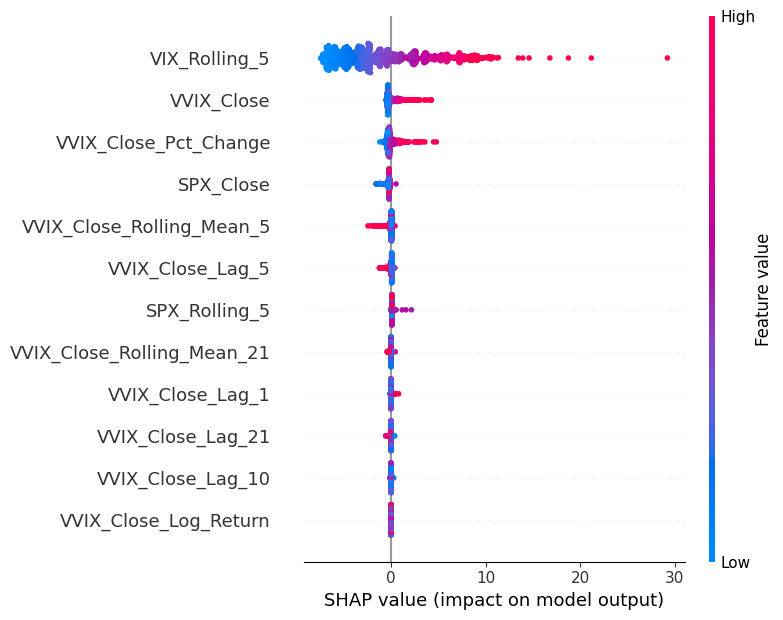

Waterfall Plot


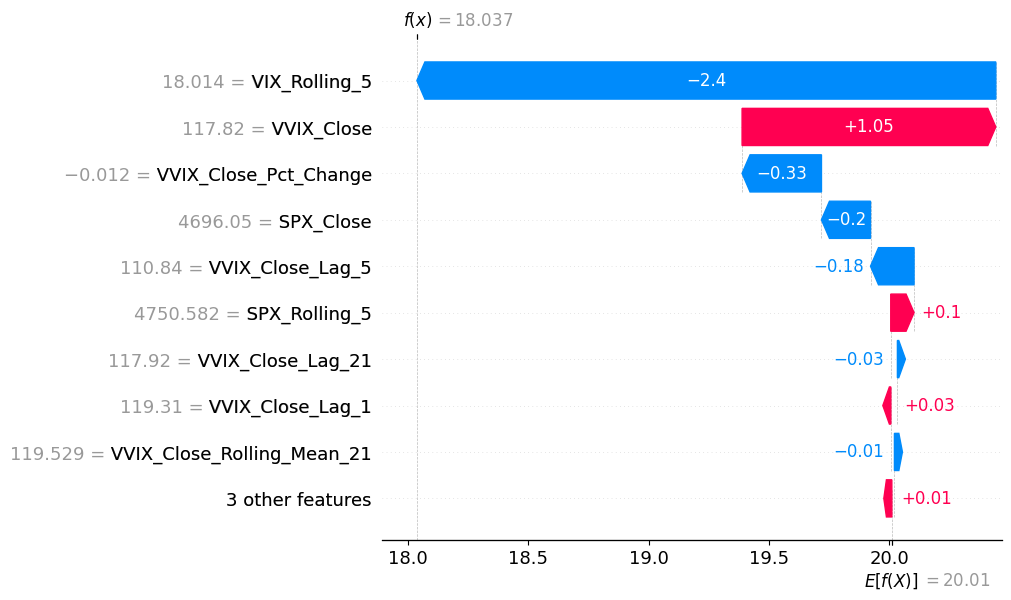

Force Plot


In [ ]:
# SHAP Analysis
import shap
from shap import TreeExplainer

# Define explanation object
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Bar Plot
print("Bar Plot")
# Calculate mean absolute SHAP values for each feature to resolve the ValueError
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)
shap.bar_plot(mean_abs_shap_values, max_display=10, feature_names=X_test.columns)

# Summary Plot
print("Summary Plot")
shap.summary_plot(shap_values, X_test)

# Create an Explanation object for a single instance for waterfall and force plots
# For example, let's take the first instance from X_test (index 0)
instance_index = 0
explanation_for_instance = shap.Explanation(
    values=shap_values[instance_index],
    base_values=explainer.expected_value,
    data=X_test.iloc[instance_index]
)

# Waterfall Plot
print("Waterfall Plot")
shap.waterfall_plot(explanation_for_instance, max_display=10)

# Force Plot
print("Force Plot")
shap.initjs()  # Initialize JS for Force Plot
shap.force_plot(explanation_for_instance)